## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd

import missingno

from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_2016_2018.csv", encoding = enc)
dataset_monthly

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2016-01,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2016,1,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,-0.106774,3.161613,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,4.884865,9.245614,9.251663,151.126434,151.430807,151.430807,-7.73,13.95,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0
1,0,2016-02,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2016,2,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,3.689048,8.390000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.712463,25.155823,42.624069,85.824574,230.092241,78.661435,-2.39,17.77,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0
2,0,2016-03,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2016,3,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,3.082903,8.906774,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,6.452221,0.575541,28.231727,197.631731,430.111107,200.018866,-7.95,25.75,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0
3,0,2016-04,EL5,βορεια ελλαδα,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,21.76334,40.79806,2,3,2,2016,4,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,9.007333,16.080000,6.430000,13.090952,14.730645,23.152667,-0.106774,3.689048,3.082903,9.007333,3.161613,8.390000,8.906774,16.080000,2.347688,41.221155,46.724297,70.430655,500.541762,70.430655,-0.25,27.47,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,

In [4]:
# dataset_monthly.cases.sum()

<Axes: >

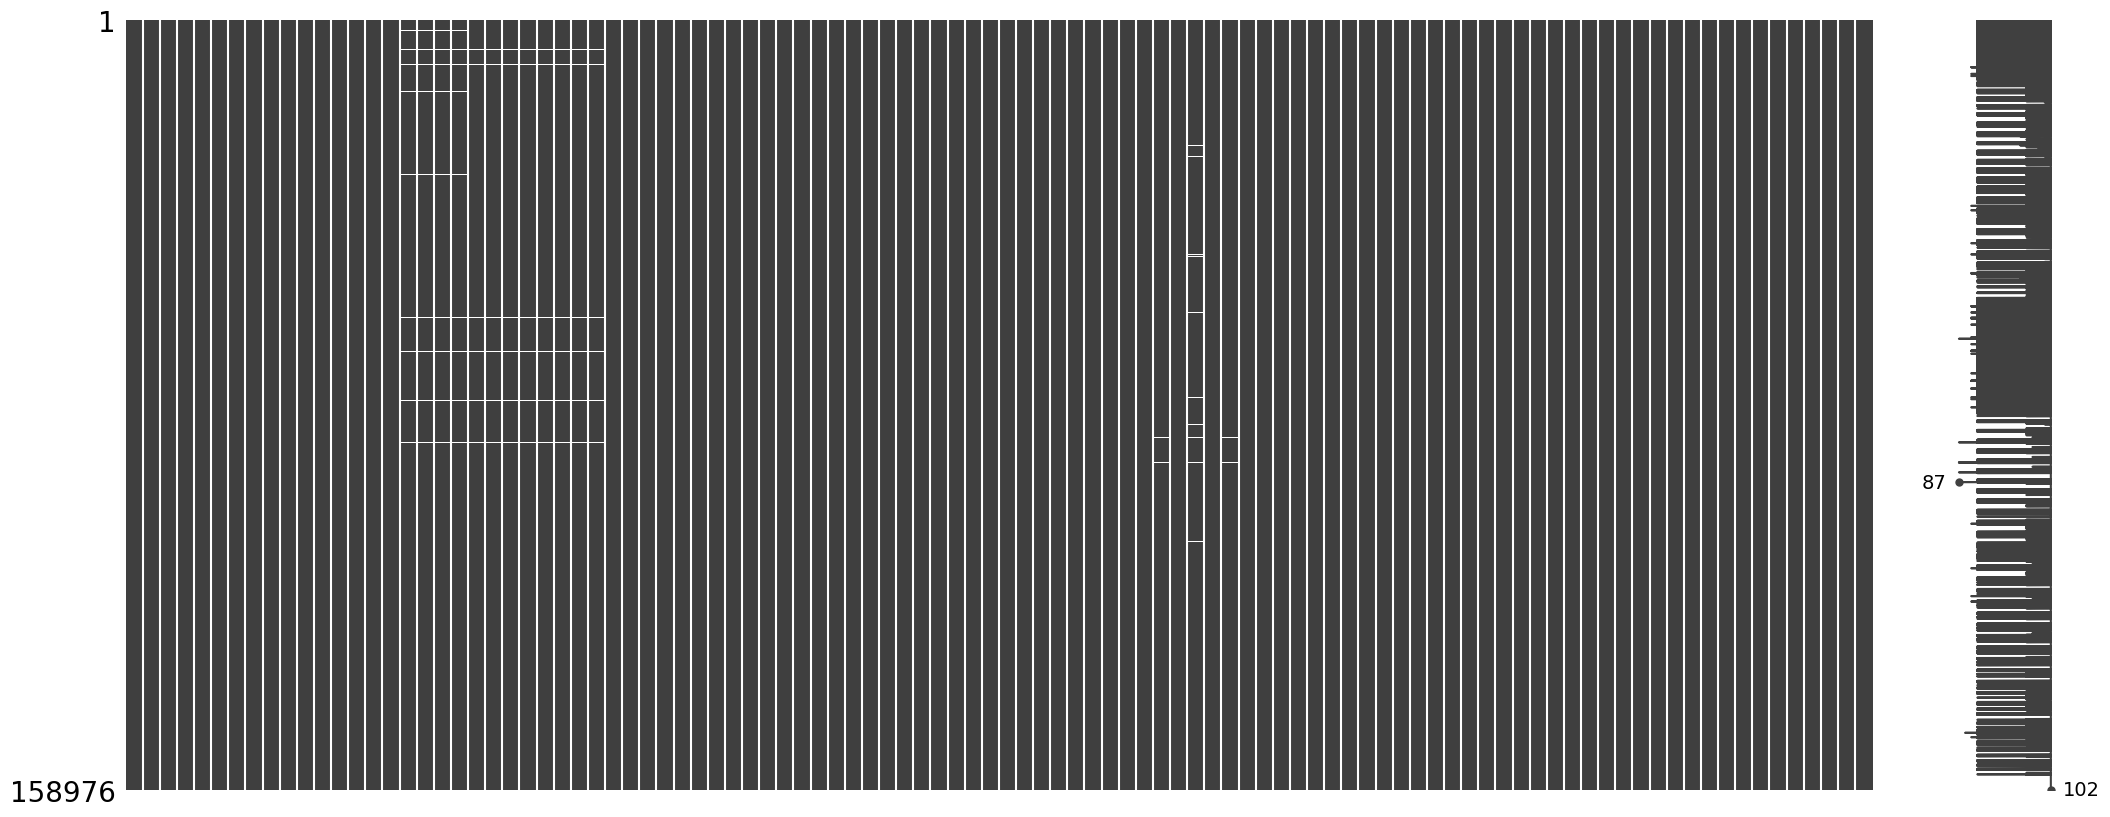

In [5]:
missingno.matrix(dataset_monthly)

In [6]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
16,ndvi,1.9739
17,ndmi,1.9739
18,ndwi,1.9739
19,ndbi,1.9739
20,ndvi_mean,1.4656
21,ndmi_mean,1.4656
22,ndwi_mean,1.4656
23,ndbi_mean,1.4656
24,ndvi_std,1.4656
25,ndmi_std,1.4656


In [7]:
all_columns = dataset_monthly.columns.to_list()

In [8]:
len(dataset_monthly.columns)

102

In [9]:
desired_order = ['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME', 'cell_number', 'x','y','month','year',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst_day_mean','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean',
 'lst_night_mean','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean',
 'lst_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean','lst_min','lst_max',
 'rainfall_mean','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'lc_prop1','lc_prop1_assessment','lc_prop2','lc_prop2_assessment','lc_prop3','lc_prop3_assessment','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw','qc',
 'M_Y_LT15','M_Y15-64','M_Y_GE65','M_TOTAL','F_Y_LT15','F_Y15-64','F_Y_GE65','F_TOTAL','MIO_EUR','L_TOTAL','UNL_TOTAL',
 'MOUNT_TYPE', 'URBN_TYPE', 'COAST_TYPE',
 ]

In [10]:
len(desired_order)

99

In [11]:
diff1 = set(desired_order) - set(all_columns)
diff2 = set(all_columns) - set(desired_order)

# Combine the differences
result = list(diff1.union(diff2))

In [12]:
result

['rainfall_acc', 'NUTS1_ID', 'NUTS1_NAME']

In [13]:
dataset_monthly = dataset_monthly[desired_order].copy()

In [14]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,2016-01,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,1,2016,0.316791,-0.084546,-0.309917,0.084546,0.307212,-0.080409,-0.302734,0.080409,0.011876,0.043161,0.014922,0.043161,6.430000,6.430000,13.090952,14.730645,23.152667,-0.106774,-0.106774,3.689048,3.082903,9.007333,3.161613,3.161613,8.390000,8.906774,16.080000,-7.73,13.95,4.884865,9.245614,9.251663,151.126434,151.430807,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
1,2016-02,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,2,2016,0.308753,-0.085701,-0.307401,0.085701,0.293227,-0.078442,-0.297639,0.078442,0.011203,0.059706,0.017973,0.059706,13.090952,6.430000,13.090952,14.730645,23.152667,3.689048,-0.106774,3.689048,3.082903,9.007333,8.390000,3.161613,8.390000,8.906774,16.080000,-2.39,17.77,2.712463,25.155823,42.624069,85.824574,230.092241,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
2,2016-03,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,3,2016,0.170068,-0.005780,-0.182944,0.005780,0.188196,0.035042,-0.163391,-0.035042,0.046762,0.052049,0.056384,0.052049,14.730645,6.430000,13.090952,14.730645,23.152667,3.082903,-0.106774,3.689048,3.082903,9.007333,8.906774,3.161613,8.390000,8.906774,16.080000,-7.95,25.75,6.452221,0.575541,28.231727,197.631731,430.111107,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
3,2016-04,EL52,κεντρικη μακεδονια,EL524,πελλα,εδεσσας,0,21.76334,40.79806,4,2016,0.415760,0.014507,-0.360760,-0.014507,0.394405,0.015751,-0.349497,-0.015751,0.037912,0.039548,0.025293,0.039548,23.152667,6.430000,13.090952,14.730645,23.152667,9.007333,-0.106774,3.689048,3.082903,9.007333,16.080000,3.161613,8.390000,8.906774,16.080000,-0.25,27.47,2.347688,41.221155,46.724297,70.430655,500.541762,13.250000,23.666667,52.592593,861.420603,37.0,-8.0,45.0,19.0,6.166667,24.833333,2.833333,1461.0,285.0,18.0,63.870641,544.0,225.0,242.0,243.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.000000,22,70.0,20,70.0,20,70.0,9,9,4,4,4,2,0,10079.0,43293.0,15016.0,68388.0,9699.0,42791.0,18227.0,70717.0,1586.15,4748.0,3514.0,2,3,2
4,2016-05,EL52,κεντρικη μακε

In [15]:
years = dataset_monthly.year.unique()
months =  dataset_monthly.month.unique()
cell_codes = dataset_monthly.cell_number.unique()

In [16]:
data = []

for year in years[1:]:
    for month in months:
        print(f'Year: {year} | Month: {month}')
        for cell in cell_codes:
            df_regional = dataset_monthly.loc[(dataset_monthly['cell_number'] == cell)].copy()
            df_regional.reset_index(drop = True, inplace = True)

            df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
            if month == 1:
                df_prev_month = df_regional.loc[(df_regional['year'] == year-1) & (df_regional['month'] == 12)].copy()
            else:
                df_prev_month = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month -1)].copy()

            df_curr_year = df_regional.loc[(df_regional['year'] == year) & (df_regional['month'] == month)].copy()
        
            data.append({'cell_number': cell,
                        'nuts2_id': df_curr_year.iloc[0]['NUTS2_ID'],
                        'nuts3_id': df_curr_year.iloc[0]['NUTS3_ID'],
                        'lau1': df_curr_year.iloc[0]['LAU1_NAME'], 
                        'year': year, 
                        'month': month,
                        'x' : df_curr_year.iloc[0]['x'],
                        'y': df_curr_year.iloc[0]['y'],
                        'ndvi': df_prev_month.iloc[0]['ndvi'],
                        'ndmi': df_prev_month.iloc[0]['ndmi'],
                        'ndwi': df_prev_month.iloc[0]['ndwi'],
                        'ndbi': df_prev_month.iloc[0]['ndbi'],
                        'ndvi_mean': df_prev_month.iloc[0]['ndvi_mean'],
                        'ndmi_mean': df_prev_month.iloc[0]['ndmi_mean'],
                        'ndwi_mean': df_prev_month.iloc[0]['ndwi_mean'],
                        'ndbi_mean': df_prev_month.iloc[0]['ndbi_mean'],
                        'ndvi_std': df_prev_month.iloc[0]['ndvi_std'],
                        'ndmi_std': df_prev_month.iloc[0]['ndmi_std'],
                        'ndwi_std': df_prev_month.iloc[0]['ndwi_std'],
                        'ndbi_std': df_prev_month.iloc[0]['ndbi_std'],

                        'lst_day_mean': df_prev_month.iloc[0]['lst_day_mean'],
                        'lst_jan_day_mean': df_curr_year.iloc[0]['lst_jan_day_mean'],
                        'lst_feb_day_mean': df_curr_year.iloc[0]['lst_feb_day_mean'],
                        'lst_mar_day_mean': df_curr_year.iloc[0]['lst_mar_day_mean'],
                        'lst_apr_day_mean': df_curr_year.iloc[0]['lst_apr_day_mean'],

                        'lst_night_mean': df_prev_month.iloc[0]['lst_night_mean'],
                        'lst_jan_night_mean': df_curr_year.iloc[0]['lst_jan_night_mean'],
                        'lst_feb_night_mean': df_curr_year.iloc[0]['lst_feb_night_mean'],
                        'lst_mar_night_mean': df_curr_year.iloc[0]['lst_mar_night_mean'],
                        'lst_apr_night_mean': df_curr_year.iloc[0]['lst_apr_night_mean'],

                        'lst_mean': df_prev_month.iloc[0]['lst_mean'],
                        'lst_jan_mean': df_curr_year.iloc[0]['lst_jan_mean'],
                        'lst_feb_mean': df_curr_year.iloc[0]['lst_feb_mean'],
                        'lst_mar_mean': df_curr_year.iloc[0]['lst_mar_mean'],
                        'lst_apr_mean': df_curr_year.iloc[0]['lst_apr_mean'],

                        'monthly_lst_min': df_prev_month.iloc[0]['lst_min'],
                        'monthly_lst_max': df_prev_month.iloc[0]['lst_max'],

                        'rainfall_mean': df_prev_month.iloc[0]['rainfall_mean'],
                        'acc_rainfall_1week': df_prev_month.iloc[0]['acc_rainfall_1week'],
                        'acc_rainfall_2week': df_prev_month.iloc[0]['acc_rainfall_2week'],
                        'acc_rainfall_month': df_prev_month.iloc[0]['acc_rainfall_month'],
                        'acc_rainfall_jan': df_curr_year.iloc[0]['acc_rainfall_jan'],

                        'bio1': df_prev_year.iloc[0]['bio1'],
                        'bio2': df_prev_year.iloc[0]['bio2'],
                        'bio3': df_prev_year.iloc[0]['bio3'],
                        'bio4': df_prev_year.iloc[0]['bio4'],
                        'bio5': df_prev_year.iloc[0]['bio5'],
                        'bio6': df_prev_year.iloc[0]['bio6'],
                        'bio7': df_prev_year.iloc[0]['bio7'],
                        'bio8': df_prev_year.iloc[0]['bio8'],
                        'bio9': df_prev_year.iloc[0]['bio9'],
                        'bio10': df_prev_year.iloc[0]['bio10'],
                        'bio11': df_prev_year.iloc[0]['bio11'],
                        'bio12': df_prev_year.iloc[0]['bio12'],
                        'bio13': df_prev_year.iloc[0]['bio13'],
                        'bio14': df_prev_year.iloc[0]['bio14'],
                        'bio15': df_prev_year.iloc[0]['bio15'],
                        'bio16': df_prev_year.iloc[0]['bio16'],
                        'bio17': df_prev_year.iloc[0]['bio17'],
                        'bio18': df_prev_year.iloc[0]['bio18'],
                        'bio19': df_prev_year.iloc[0]['bio19'],

                        'lc_prop1': df_curr_year.iloc[0]['lc_prop1'],
                        'lc_prop2': df_curr_year.iloc[0]['lc_prop2'],
                        'lc_prop3': df_curr_year.iloc[0]['lc_prop3'],
                        'lc_type1': df_curr_year.iloc[0]['lc_type1'],
                        'lc_type2': df_curr_year.iloc[0]['lc_type2'],
                        'lc_type3': df_curr_year.iloc[0]['lc_type3'],
                        'lc_type4': df_curr_year.iloc[0]['lc_type4'],
                        'lc_type5': df_curr_year.iloc[0]['lc_type5'],

                        'distance_to_coast': df_curr_year.iloc[0]['distance_to_coast'],
                        'distance_to_river': df_curr_year.iloc[0]['distance_to_river'],
                        'slope_mean_1km': df_curr_year.iloc[0]['slope_mean_1km'],
                        'aspect_mean_200m': df_curr_year.iloc[0]['aspect_mean_200m'],
                        'elevation_mean_1km': df_curr_year.iloc[0]['elevation_mean_1km'],
                        'hillshade_mean_1km': df_curr_year.iloc[0]['hillshade_mean_1km'],
                        'fs_area_1km': df_curr_year.iloc[0]['fs_area_1km'],
                        'flow_accu_200m': df_curr_year.iloc[0]['flow_accu_200m'],

                        'males_lt15': df_prev_year.iloc[0]['M_Y_LT15'],
                        'males_15t64': df_prev_year.iloc[0]['M_Y15-64'],
                        'males_gt65': df_prev_year.iloc[0]['M_Y_GE65'],
                        'males_total': df_prev_year.iloc[0]['M_TOTAL'],
                        'females_lt15': df_prev_year.iloc[0]['F_Y_LT15'],
                        'females_15t64': df_prev_year.iloc[0]['F_Y15-64'],
                        'females_gt65': df_prev_year.iloc[0]['F_Y_GE65'],
                        'females_total': df_prev_year.iloc[0]['F_TOTAL'],
                        'mio_eur': df_prev_year.iloc[0]['MIO_EUR'],
                        'l_total': df_prev_year.iloc[0]['L_TOTAL'],
                        'unl_total': df_prev_year.iloc[0]['UNL_TOTAL'],

                        'mount_type': df_prev_month.iloc[0]['MOUNT_TYPE'],
                        'urbn_type': df_prev_month.iloc[0]['URBN_TYPE'],
                        'coast_type': df_prev_month.iloc[0]['COAST_TYPE'],
                    
                        # 'cases': df_curr_year.iloc[0]['cases'],
                        })
        
dataset_operational = pd.DataFrame(data)       

Year: 2017 | Month: 1
Year: 2017 | Month: 2
Year: 2017 | Month: 3
Year: 2017 | Month: 4
Year: 2017 | Month: 5
Year: 2017 | Month: 6
Year: 2017 | Month: 7
Year: 2017 | Month: 8
Year: 2017 | Month: 9
Year: 2017 | Month: 10
Year: 2017 | Month: 11
Year: 2017 | Month: 12
Year: 2018 | Month: 1
Year: 2018 | Month: 2
Year: 2018 | Month: 3
Year: 2018 | Month: 4
Year: 2018 | Month: 5
Year: 2018 | Month: 6
Year: 2018 | Month: 7
Year: 2018 | Month: 8
Year: 2018 | Month: 9
Year: 2018 | Month: 10
Year: 2018 | Month: 11
Year: 2018 | Month: 12


In [17]:
dataset_monthly[(dataset_monthly['cell_number'] == 0) & (dataset_monthly['year'] == 2017)].drop(columns=['NUTS2_ID','NUTS2_NAME','NUTS3_ID','LAU1_NAME'])

,dt_placement,NUTS3_NAME,cell_number,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_min,lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
12,2017-01,πελλα,0,21.76334,40.79806,1,2017,0.309049,-0.093949,-0.291225,0.093949,0.296032,-0.096063,-0.285041,0.096063,0.016985,0.033386,0.016843,0.033386,3.481613,3.481613,9.942143,16.799032,21.175333,-2.502258,-2.502258,-3.708571,3.876452,5.038,0.489677,0.489677,3.116786,10.337742,13.106667,-12.37,8.09,3.717113,12.411311,69.819269,115.186849,115.230505,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
13,2017-02,πελλα,0,21.76334,40.79806,2,2017,0.308479,-0.095711,-0.291832,0.095711,0.295371,-0.097763,-0.285444,0.097763,0.016948,0.032865,0.016704,0.032865,9.942143,3.481613,9.942143,16.799032,21.175333,-3.708571,-2.502258,-3.708571,3.876452,5.038,3.116786,0.489677,3.116786,10.337742,13.106667,-16.05,18.41,2.160814,19.837339,21.484744,60.502786,175.733291,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
14,2017-03,πελλα,0,21.76334,40.79806,3,2017,0.303289,-0.131780,-0.310015,0.131780,0.288830,-0.131917,-0.300126,0.131917,0.018152,0.023374,0.014461,0.023374,16.799032,3.481613,9.942143,16.799032,21.175333,3.876452,-2.502258,-3.708571,3.876452,5.038,10.337742,0.489677,3.116786,10.337742,13.106667,0.33,27.41,2.721748,1.887299,4.787975,63.877216,260.107482,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
15,2017-04,πελλα,0,21.76334,40.79806,4,2017,0.328463,-0.081889,-0.326864,0.081889,0.319196,-0.077346,-0.323261,0.077346,0.030430,0.032091,0.018107,0.032091,21.175333,3.481613,9.942143,16.799032,21.175333,5.038000,-2.502258,-3.708571,3.876452,5.038,13.106667,0.489677,3.116786,10.337742,13.106667,-4.43,28.07,1.890473,18.636660,24.226872,56.714193,316.821675,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,22,74.0,20,74.0,20,74.0,9,9,4,4,4,2,0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
16,2017-05,πελλα,0,21.76334,40.79806,5,2017,0.326355,0.304048,-0.281833,-0.304048,0.410773,0.259706,-0.347347,-0.259706,0.048771,0.047147,0.034800,0.047147,25.750000,3.481613,9.942143,16.799032,21.175333,12.761613,-2.502258,-3.708571,3.876452,5.038,19.25

In [18]:
dataset_operational[(dataset_operational['cell_number'] == 0) & (dataset_operational['year'] == 2018)]

,cell_number,nuts2_id,nuts3_id,lau1,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,mount_type,urbn_type,coast_type
52992,0,EL52,EL524,εδεσσας,2018,1,21.76334,40.79806,0.313319,-0.080928,-0.300870,0.080928,0.297286,-0.090610,-0.287572,0.090610,0.022688,0.035234,0.018563,0.035234,7.833871,7.635806,8.97,14.336452,25.177333,0.300323,0.506774,-0.205714,1.289355,10.158667,4.067097,4.07129,4.382143,7.812903,17.668,-9.93,11.87,5.034564,3.981100,19.292321,52.512288,69.254835,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
57408,0,EL52,EL524,εδεσσας,2018,2,21.76334,40.79806,0.319202,-0.086139,-0.310332,0.086139,0.297922,-0.092702,-0.291458,0.092702,0.023501,0.038212,0.020091,0.038212,7.635806,7.635806,8.97,14.336452,25.177333,0.506774,0.506774,-0.205714,1.289355,10.158667,4.071290,4.07129,4.382143,7.812903,17.668,-3.85,12.31,2.234027,0.000000,8.442638,69.226505,322.818751,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
61824,0,EL52,EL524,εδεσσας,2018,3,21.76334,40.79806,0.236966,-0.029234,-0.190846,0.029234,0.248994,-0.068811,-0.234002,0.068811,0.045599,0.050486,0.079280,0.050486,8.970000,7.635806,8.97,14.336452,25.177333,-0.205714,0.506774,-0.205714,1.289355,10.158667,4.382143,4.07129,4.382143,7.812903,17.668,-8.91,11.45,9.055854,17.673727,74.342291,253.563917,544.918971,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
66240,0,EL52,EL524,εδεσσας,2018,4,21.76334,40.79806,0.262942,0.010000,-0.258764,-0.010000,0.237641,0.013810,-0.238012,-0.013810,0.055625,0.079659,0.060062,0.079659,14.336452,7.635806,8.97,14.336452,25.177333,1.289355,0.506774,-0.205714,1.289355,10.158667,7.812903,4.07129,4.382143,7.812903,17.668,-7.93,22.57,7.164523,12.133546,72.854002,207.481879,571.530628,13.625,24.916667,43.71345,1052.513226,41.0,-16.0,57.0,1.666667,19.666667,26.666667,0.0,1245.0,284.0,38.0,66.775079,555.0,151.0,208.0,331.0,22,20,20,9,9,4,4,4,1448.145975,456.840006,9,75.660308,748.319206,158.266121,0.0,1.0,9893.0,43105.0,15149.0,68147.0,9443.0,42645.0,18348.0,70436.0,1598.93,3662.0,2056.0,2,3,2
70656,0,EL52,EL524,εδεσσας,2018,5,21.76334,40.79806,0.408381,-0.065172,-0.369258,0.065172,0.357442,-0.025376,-0.313345,0.025376,0.041805,0.049805,0.040286,0.049805,25.177333,7.635806,8.97,14.336452,25.177333,10.158667,0.506774,-0.205714,1.289355,10.158667,17.668000,4.07129,4.382143,7.812903,17.668,4.01,32.27,0.887055,8.326400,8.693120,26.611657,7

<Axes: >

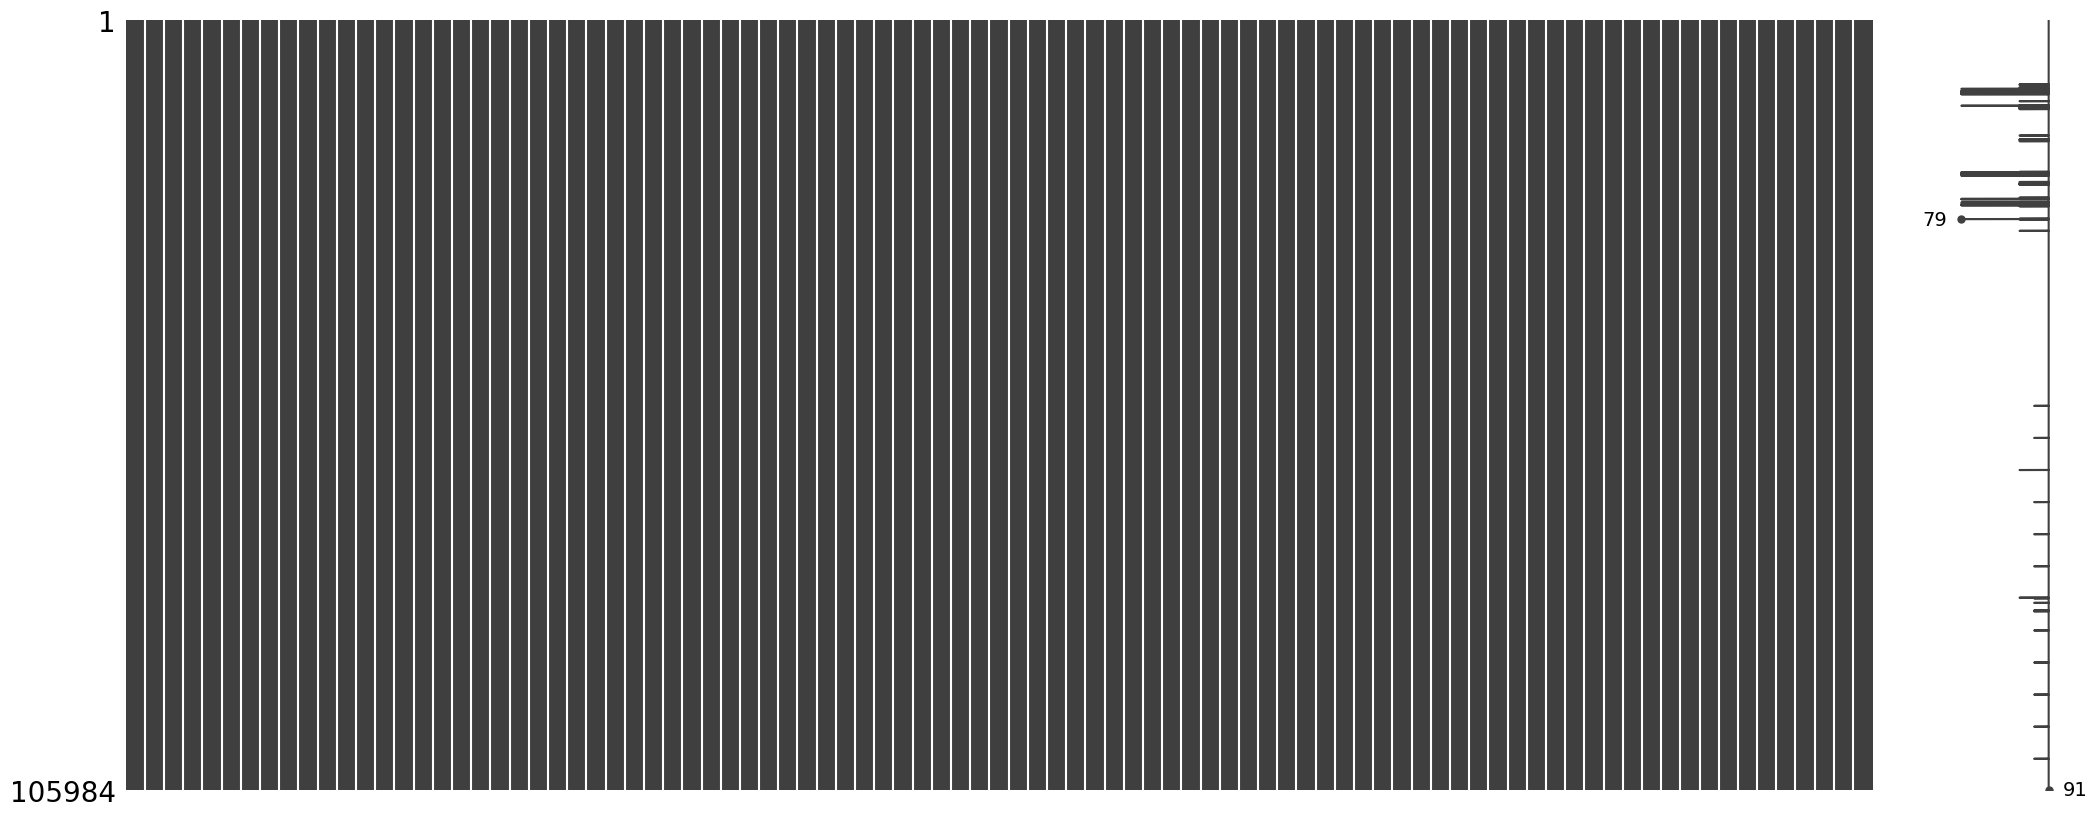

In [19]:
missingno.matrix(dataset_operational)

In [20]:
missing = describe_dataframe(dataset_operational, remove_zeros=True)
missing

,Column,Missing
8,ndvi,0.1425
9,ndmi,0.1425
10,ndwi,0.1425
11,ndbi,0.1425
12,ndvi_mean,0.0670
13,ndmi_mean,0.0670
14,ndwi_mean,0.0670
15,ndbi_mean,0.0670
16,ndvi_std,0.0670
17,ndmi_std,0.0670


In [21]:
# dataset_monthly.cases.sum()

In [22]:
# dataset_operational.cases.sum()

In [23]:
dataset_operational.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_OP_2017_2018.csv", encoding = enc, index = False)